In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub


/kaggle/input/datasets/mikhail1681/walmart-sales/Walmart_Sales.csv


# 1. Load the Dataset

In [2]:
# Import file tools
import os

# Show attached datasets
os.listdir('/kaggle/input')# kagglehub.dataset_download('<owner>/<dataset-slug>')


['datasets']

In [3]:
# Show dataset files
os.listdir('/kaggle/input')

['datasets']

In [4]:
# Import pandas
import pandas as pd

# Load dataset
walmart_df = pd.read_csv(
    '/kaggle/input/datasets/mikhail1681/walmart-sales/Walmart_Sales.csv'
)

# Preview the first five rows
walmart_df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# 2. Dataset Inspection

In [5]:
# Check dataset dimensions
walmart_df.shape

(6435, 8)

In [6]:
# Show column names
walmart_df.columns.tolist()

['Store',
 'Date',
 'Weekly_Sales',
 'Holiday_Flag',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment']

In [7]:
# Inspect dataset structure
walmart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


### Initial Inspection Findings

- The dataset contains 6,435 rows and 8 columns.
- All columns contain 6,435 non-null values, indicating no obvious missing data.
- Most numeric columns already have appropriate numeric data types.
- The Date column is currently stored as an object and will need to be converted to a datetime data type.
- Weekly_Sales is the primary measure for the sales analysis.
- Store and Holiday_Flag can be used for grouped comparisons.
- Temperature, Fuel_Price, CPI, and Unemployment can be examined as external factors potentially associated with sales.

# 3. Data Quality Assessment

In [8]:
# Count missing values
walmart_df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [9]:
# Count duplicate rows
walmart_df.duplicated().sum()

np.int64(0)

### Data Quality Findings

- No missing values were identified in any of the dataset columns.
- No fully duplicated rows were detected.
- The dataset does not require missing-value imputation or duplicate removal.
- The Date column still requires conversion from object to datetime.
- Additional validation will be performed to check for invalid or unusual values before analysis.

# 4. Data Validation

In [10]:
# Generate descriptive statistics
walmart_df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [11]:
# Show unique flag values
walmart_df['Holiday_Flag'].unique()

array([0, 1])

In [12]:
# Count unique stores
walmart_df['Store'].nunique()

45

### Data Validation Findings

- The dataset contains 45 unique Walmart stores.
- Store IDs range from 1 to 45.
- Holiday_Flag contains only valid values: 0 and 1.
- No missing values were found.
- No duplicate rows were found.
- No obvious invalid numeric values were identified from the descriptive statistics.

# 5. Data Cleaning

In [13]:
# Convert Date to datetime
walmart_df['Date'] = pd.to_datetime(walmart_df['Date'], format='%d-%m-%Y')

# Chech the updated data type
walmart_df['Date'].dtype

dtype('<M8[ns]')

### Data Cleaning Result

The Date column was successfully converted from an object data type to datetime64[ns].

This conversion is important because it allows the dataset to support time-based analysis such as extracting years and months, sorting records chronologically, and analyzing sales trends over time.

# 6. Feature Engineering

In [14]:
# Create year column
walmart_df['Year'] = walmart_df['Date'].dt.year

# Create month column
walmart_df['Month'] = walmart_df['Date'].dt.month

# Create month name column
walmart_df['Month_Name'] = walmart_df['Date'].dt.month_name()

# Preview new columns
walmart_df[['Date','Year','Month','Month_Name']].head()

,Date,Year,Month,Month_Name
0,2010-02-05,2010,2,February
1,2010-02-12,2010,2,February
2,2010-02-19,2010,2,February
3,2010-02-26,2010,2,February
4,2010-03-05,2010,3,March


### Feature Engineering Findings

- Year, Month, and Month_Name were successfully extracted from the Date column.
- These features will support year-over-year and month-level sales analysis.
- The engineered time variables make it easier to aggregate and compare sales across different periods.

# 7. Create a KPI Summary Function

In [15]:
# Define currency formatting function
def format_currency(value):
    # Format value as currency
    return f'${value:,.2f}'

# Define a function for sales summary
def sales_summary(df, column):

    # Calculate total
    total = df[column].sum()

    # Calculate average
    average = df[column].mean()

    #Find lowest sales
    minimum = df[column].min()

    # Find highest sales
    maximum = df[column].max()

    # Create summary table
    summary_df = pd.DataFrame({
        'Metric': ['Total Sales','Average Weekly Sales','Minimum Weekly Sales','Maximum Weekly Sales'],
        'Calculated_Value': [total, average, minimum, maximum]
    })
    
    # Format calculated values as currency
    summary_df['Raw_Value'] = summary_df['Calculated_Value'].apply(format_currency)

    # Return summary table
    return summary_df

# Create sales KPI summary
sales_kpis = sales_summary(walmart_df,'Weekly_Sales')


# Display KPI summary
sales_kpis

,Metric,Calculated_Value,Raw_Value
0,Total Sales,6.737219e+09,"$6,737,218,987.11"
1,Average Weekly Sales,1.046965e+06,"$1,046,964.88"
2,Minimum Weekly Sales,2.099862e+05,"$209,986.25"
3,Maximum Weekly Sales,3.818686e+06,"$3,818,686.45"


### Sales KPI Findings

- Total recorded sales across all store-week observations were approximately **\$6.74 billion**.
- Average weekly sales per store-week observation were approximately **\$1.05 million**.
- The minimum weekly sales observation was approximately **\$209,986**.
- The maximum weekly sales observation was approximately **\$3.82 million**.
- The large gap between the minimum and maximum weekly sales indicates substantial variation across stores and time periods, which supports further store-level and time-based analysis.

In [16]:
# Calculate total sales by store
store_sales = walmart_df.groupby('Store')['Weekly_Sales'].sum()

# Sort stores from highest to lowest
store_sales = store_sales.sort_values(ascending=False)

# Convert the Series into a DataFrame
store_sales = store_sales.reset_index(name='Total_Sales')

# Rank the stores
store_sales['Rank'] = (
    store_sales['Total_Sales']
    .rank(ascending=False, method='dense')
    .astype(int)
)

# Format total sales by currency
store_sales['Formatted_Sales'] = store_sales['Total_Sales'].apply(format_currency)

# Reorder columns for readability
store_sales = store_sales[['Rank','Store','Total_Sales','Formatted_Sales']]

# Display the top 10 stores
store_sales.head(10)

,Rank,Store,Total_Sales,Formatted_Sales
0,1,20,3.013978e+08,"$301,397,792.46"
1,2,4,2.995440e+08,"$299,543,953.38"
2,3,14,2.889999e+08,"$288,999,911.34"
3,4,13,2.865177e+08,"$286,517,703.80"
4,5,2,2.753824e+08,"$275,382,440.98"
5,6,10,2.716177e+08,"$271,617,713.89"
6,7,27,2.538559e+08,"$253,855,916.88"
7,8,6,2.237561e+08,"$223,756,130.64"
8,9,1,2.224028e+08,"$222,402,808.85"
9,10,39,2.074455e+08,"$207,445,542.47"


### Total Sales by Store Findings

- Store 20 ranked first with approximately **\$301.40 million** in total sales.
- Store 4 ranked second with approximately **\$299.54 million**, followed by Store 14 with approximately **\$289.00 million**.
- The relatively small difference between Stores 20 and 4 indicates that both were leading contributors to total sales during the observed period.
- The ranking identifies stores with the greatest cumulative sales contribution; average weekly sales will be analyzed separately to evaluate typical weekly performance.

# 8. Average Weekly Sales by Store

In [17]:
# Calculate average weekly sales by store
store_avg_sales = walmart_df.groupby('Store')['Weekly_Sales'].mean()

# Sort stores from highest to lowest
store_avg_sales = store_avg_sales.sort_values(ascending=False)

# Convert the Series into a DataFrame
store_avg_sales = store_avg_sales.reset_index(name='Average_Weekly_Sales')

# Rank stores by average weekly sales
store_avg_sales['Rank'] = (
    store_avg_sales['Average_Weekly_Sales']
    .rank(ascending=False, method='dense')
    .astype(int)
)

# Format average weekly sales
store_avg_sales['Formatted_Avg_Sales'] = store_avg_sales['Average_Weekly_Sales'].apply(format_currency)

# Reorder columns for readability
store_avg_sales = store_avg_sales[
    ['Rank', 'Store', 'Average_Weekly_Sales', 'Formatted_Avg_Sales']
]

# Display the top 10 stores
store_avg_sales.head(10)

,Rank,Store,Average_Weekly_Sales,Formatted_Avg_Sales
0,1,20,2.107677e+06,"$2,107,676.87"
1,2,4,2.094713e+06,"$2,094,712.96"
2,3,14,2.020978e+06,"$2,020,978.40"
3,4,13,2.003620e+06,"$2,003,620.31"
4,5,2,1.925751e+06,"$1,925,751.34"
5,6,10,1.899425e+06,"$1,899,424.57"
6,7,27,1.775216e+06,"$1,775,216.20"
7,8,6,1.564728e+06,"$1,564,728.19"
8,9,1,1.555264e+06,"$1,555,264.40"
9,10,39,1.450668e+06,"$1,450,668.13"


### Average Weekly Sales by Store Findings

- Store 20 had the highest average weekly sales at approximately **\$2.11 million**.
- Store 4 ranked second at approximately **\$2.09 million**, followed by Store 14 at approximately **\$2.02 million**.
- The ranking by average weekly sales matches the ranking by total sales for the leading stores.
- This suggests that stores may contain the same number of weekly observations, which should be verified before comparing the two measures further.

In [18]:
# Count weekly observations for each store
store_counts = walmart_df.groupby('Store').size()

# Display observation counts
store_counts

# Check unique observation counts
store_counts.unique()

array([143])

### Observation Count Validation

- Each of the 45 stores contains exactly **143 weekly observations**.
- Because all stores have the same number of observations, the ranking by total sales is identical to the ranking by average weekly sales.
- Total sales measure cumulative contribution, while average weekly sales describe typical weekly performance.
- Since observation counts are equal, both measures provide consistent store rankings in this dataset.

# 9. Sales Variability by Store

In [19]:
# Calculate weekly sales standard deviation by store
store_sales_variability = (
    walmart_df
    .groupby('Store')
    .agg(
        Average_Weekly_Sales = ('Weekly_Sales', 'mean'),
        Sales_Std_Dev = ('Weekly_Sales', 'std')
    ).reset_index()
)

# Rank stores by average weekly sales
store_sales_variability['Rank'] = (
    store_sales_variability['Sales_Std_Dev']
    .rank(ascending=False, method='dense')
    .astype(int)
)

# Sort stores from highest to lowest average sales
store_sales_variability = (
    store_sales_variability
    .sort_values('Sales_Std_Dev', ascending=False)
    .reset_index(drop=True)
)

# Reorder columns for readability
store_sales_variability = store_sales_variability[
    ['Rank', 'Store', 'Average_Weekly_Sales', 'Sales_Std_Dev']
]

# Format average sales as currency
store_sales_variability['Average_Weekly_Sales'] = (
    store_sales_variability['Average_Weekly_Sales']
    .apply(format_currency)
)

# Format standard deviation as currency
store_sales_variability['Sales_Std_Dev'] = (
    store_sales_variability['Sales_Std_Dev']
    .apply(format_currency)
)

# Display top 10 stores
store_sales_variability.head(10)

,Rank,Store,Average_Weekly_Sales,Sales_Std_Dev
0,1,14,"$2,020,978.40","$317,569.95"
1,2,10,"$1,899,424.57","$302,262.06"
2,3,20,"$2,107,676.87","$275,900.56"
3,4,4,"$2,094,712.96","$266,201.44"
4,5,13,"$2,003,620.31","$265,507.00"
5,6,23,"$1,389,864.46","$249,788.04"
6,7,27,"$1,775,216.20","$239,930.14"
7,8,2,"$1,925,751.34","$237,683.69"
8,9,39,"$1,450,668.13","$217,466.45"
9,10,6,"$1,564,728.19","$212,525.86"


### Sales Variability Findings

- Store 14 had the highest weekly sales standard deviation at approximately **\$317,570**, indicating the largest absolute week-to-week sales fluctuations among the stores.
- Store 10 ranked second at approximately **\$302,262**, followed by Store 20 at approximately **\$275,901**.
- Standard deviation measures absolute variation in weekly sales, so stores with higher average sales may naturally show larger fluctuations.
- A relative variability measure is needed to compare sales consistency more fairly across stores of different sales levels.

# 10. Coefficient of Variation

In [20]:
# Calculate mean and standard deviation by store
store_variability = walmart_df.groupby('Store')['Weekly_Sales'].agg(['mean','std'])

# Rename columns
store_variability = store_variability.rename(
    columns={'mean':'Average_Weekly_Sales','std':'Sales_Std_Dev'}
)

# Calculate coefficient variation
store_variability['CV_Percent'] = (
    (store_variability['Sales_Std_Dev'] /
    store_variability['Average_Weekly_Sales']) * 100
).round(2)

# Sort from highest to lowest
store_variability = store_variability.sort_values(by='CV_Percent', ascending = False)

# Format currency columns
store_variability[['Average_Weekly_Sales', 'Sales_Std_Dev']] = (
    store_variability[['Average_Weekly_Sales', 'Sales_Std_Dev']]
    .map(format_currency)
)

# Reset index
store_variability = store_variability.reset_index()

# Display the top 10 stores
store_variability.head(10)

,Store,Average_Weekly_Sales,Sales_Std_Dev,CV_Percent
0,35,"$919,724.98","$211,243.46",22.97
1,7,"$570,617.31","$112,585.47",19.73
2,15,"$623,312.47","$120,538.65",19.34
3,29,"$539,451.43","$99,120.14",18.37
4,23,"$1,389,864.46","$249,788.04",17.97
5,21,"$756,069.08","$128,752.81",17.03
6,45,"$785,981.41","$130,168.53",16.56
7,16,"$519,247.73","$85,769.68",16.52
8,18,"$1,084,718.42","$176,641.51",16.28
9,36,"$373,511.99","$60,725.17",16.26


### Relative Sales Variability Findings

- Store 35 had the highest coefficient of variation at **22.97%**, indicating the greatest relative variability in weekly sales.
- Stores 7 and 15 followed with coefficients of variation of **19.73%** and **19.34%**, respectively.
- The coefficient of variation produces a different ranking from standard deviation because it adjusts sales variability for each store's average sales level.
- Standard deviation is useful for measuring fluctuations in dollar terms, while the coefficient of variation is more appropriate for comparing relative sales consistency across stores with different average sales levels.

# 11. Sales Trend Analysis

In [21]:
# Calculate total sales for each week
weekly_sales = walmart_df.groupby('Date')['Weekly_Sales'].sum()

# Convert the series into DataFrame
weekly_sales = weekly_sales.reset_index(name='Total_Weekly_Sales')

# Sort observations chronologically
weekly_sales = weekly_sales.sort_values('Date')

# Format weekly sales as currency
weekly_sales['Formatted_Sales'] = weekly_sales['Total_Weekly_Sales'].apply(format_currency)

# Display the firs 10 weeks
weekly_sales.head(10)

,Date,Total_Weekly_Sales,Formatted_Sales
0,2010-02-05,49750740.50,"$49,750,740.50"
1,2010-02-12,48336677.63,"$48,336,677.63"
2,2010-02-19,48276993.78,"$48,276,993.78"
3,2010-02-26,43968571.13,"$43,968,571.13"
4,2010-03-05,46871470.30,"$46,871,470.30"
5,2010-03-12,45925396.51,"$45,925,396.51"
6,2010-03-19,44988974.64,"$44,988,974.64"
7,2010-03-26,44133961.05,"$44,133,961.05"
8,2010-04-02,50423831.26,"$50,423,831.26"
9,2010-04-09,47365290.44,"$47,365,290.44"


### Weekly Sales Trend Findings

- Weekly sales across all stores generally ranged between approximately **\$44 million and \$50 million** during the first several weeks shown.
- The week of **2010-04-02** recorded the highest sales among the first ten observations at approximately **\$50.42 million**.
- Weekly sales fluctuate noticeably over time, indicating that time-based patterns and seasonal effects should be investigated further.

# 12. Create the Weekly Sales Chart

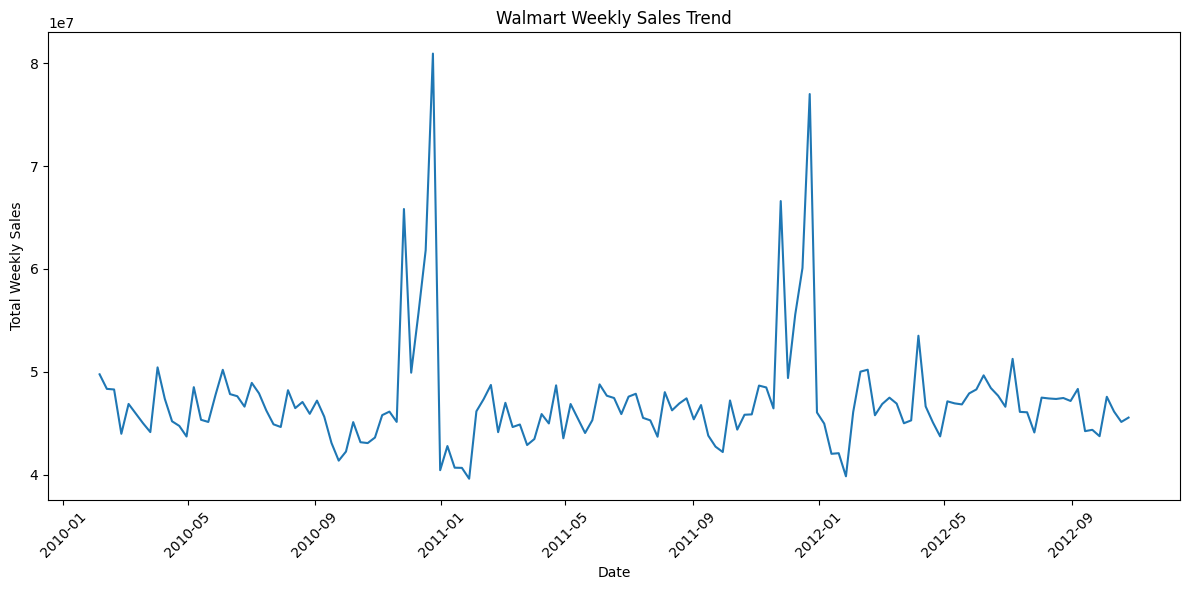

In [22]:
# Import matplotlib
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12,6))

# Plot weekly sales trend
plt.plot(
    weekly_sales['Date'],
    weekly_sales['Total_Weekly_Sales']
)

# Add chart title
plt.title('Walmart Weekly Sales Trend')

# label x-axis
plt.xlabel('Date')

# label y-axis
plt.ylabel('Total Weekly Sales')

# Rotate date labels
plt.xticks(rotation=45)

# Improve spacing
plt.tight_layout()

# Display chart
#plt.show()


### Weekly Sales Trend Findings

- Weekly sales were generally concentrated around approximately **\$40 million to \$50 million** across most of the observed period.
- Several unusually large sales spikes occurred, particularly near the end of 2010 and 2011.
- The strongest weekly sales periods were substantially above the normal weekly range, suggesting the presence of seasonal or event-driven demand.
- The recurring late-year spikes indicate that seasonality may play an important role in Walmart's weekly sales performance.
- The specific high-sales dates should be identified before determining whether holiday periods are responsible for these increases.

# 13. Identify the Highest-Sales Week

In [23]:
# Find the five highest-sales week
highest_sales_weeks = weekly_sales.nlargest(5, 'Total_Weekly_Sales')

# Display highest-sales week
highest_sales_weeks

,Date,Total_Weekly_Sales,Formatted_Sales
46,2010-12-24,80931415.60,"$80,931,415.60"
98,2011-12-23,76998241.31,"$76,998,241.31"
94,2011-11-25,66593605.26,"$66,593,605.26"
42,2010-11-26,65821003.24,"$65,821,003.24"
45,2010-12-17,61820799.85,"$61,820,799.85"


### Highest-Sales Weeks Findings

- The highest recorded weekly sales occurred on **2010-12-24**, reaching approximately **\$80.93 million**.
- The second-highest weekly sales occurred on **2011-12-23**, at approximately **\$77.00 million**.
- Other major peaks occurred on **2011-11-25** and **2010-11-26**, with sales above **\$65 million**.
- The concentration of top-sales weeks in late November and December suggests a strong seasonal pattern in Walmart sales.
- Holiday-related demand may be associated with these spikes, which will be examined directly using the `Holiday_Flag` variable.

# 14. Holiday Sales Analysis

In [24]:
# Calculate average sales by holiday
holiday_sales = walmart_df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

# Reset index
holiday_sales = holiday_sales.reset_index(name='Average_Weekly_Sales')

# Format average weekly sales as currency
holiday_sales['Formatted_Avg_Sales'] = (
    holiday_sales['Average_Weekly_Sales']
    .apply(format_currency)
)

# Display holiday sales comparison
holiday_sales

,Holiday_Flag,Average_Weekly_Sales,Formatted_Avg_Sales
0,0,1.041256e+06,"$1,041,256.38"
1,1,1.122888e+06,"$1,122,887.89"


In [25]:
# Calculate the percentage increase
non_holiday_avg = (
    holiday_sales
    .loc[holiday_sales['Holiday_Flag'] == 0,'Average_Weekly_Sales']
    .iloc[0]
)

# Store holiday average sales
holiday_avg = (
    holiday_sales
    .loc[holiday_sales['Holiday_Flag'] == 1,'Average_Weekly_Sales']
    .iloc[0]
)

# Calculate percentage difference
holiday_increase_pct = (
    (holiday_avg - non_holiday_avg) / non_holiday_avg
)*100

# Display perecentage increase
holiday_increase_pct

np.float64(7.839713033050179)

### Holiday Sales Findings

- Average weekly sales during holiday weeks were approximately **\$1.12 million**.
- Average weekly sales during non-holiday weeks were approximately **\$1.04 million**.
- Holiday weeks generated approximately **7.8% higher average sales** than non-holiday weeks.
- This indicates that holiday periods are associated with stronger weekly sales performance in the dataset.
- The result shows an association and should not be interpreted as proof that holidays alone caused the increase in sales.

# 15. Monthly Sales Analysis

In [26]:
# Create your month period
walmart_df['Year_Month'] = walmart_df['Date'].dt.to_period('M')

# Calculate total sales by year-month
monthly_sales = (
    walmart_df
    .groupby('Year_Month')['Weekly_Sales']
    .sum()
    .reset_index(name='Total_Monthly_Sales')
)

# Sort months chronologically
monthly_sales = monthly_sales.sort_values('Year_Month')

# Format monthly sales as currency
monthly_sales['Formatted_Sales'] = (
    monthly_sales['Total_Monthly_Sales']
    .apply(format_currency)
)

# Display the first 12 months
monthly_sales.head(11)

,Year_Month,Total_Monthly_Sales,Formatted_Sales
0,2010-02,1.903330e+08,"$190,332,983.04"
1,2010-03,1.819198e+08,"$181,919,802.50"
2,2010-04,2.314124e+08,"$231,412,368.05"
3,2010-05,1.867109e+08,"$186,710,934.34"
4,2010-06,1.922462e+08,"$192,246,172.36"
5,2010-07,2.325801e+08,"$232,580,125.98"
6,2010-08,1.876401e+08,"$187,640,110.89"
7,2010-09,1.772679e+08,"$177,267,896.37"
8,2010-10,2.171618e+08,"$217,161,824.02"
9,2010-11,2.028534e+08,"$202,853,370.14"


In [27]:
# Count unique weeks per month
monthly_week_counts = (
    walmart_df
    .groupby('Year_Month')['Date']
    .nunique()
    .reset_index(name='Number_of_Weeks')
)

# Display monthly week counts
monthly_week_counts.head(12)

,Year_Month,Number_of_Weeks
0,2010-02,4
1,2010-03,4
2,2010-04,5
3,2010-05,4
4,2010-06,4
5,2010-07,5
6,2010-08,4
7,2010-09,4
8,2010-10,5
9,2010-11,4


# 16. Calculate Average Sales per Month

In [28]:
# Merge monthly sales with week counts
monthly_analysis = monthly_sales.merge(
    monthly_week_counts,
    on='Year_Month'
)

# Calculate average total sales per week
monthly_analysis['Average_Weekly_Sales'] = (
    monthly_analysis['Total_Monthly_Sales'] / 
    monthly_analysis['Number_of_Weeks']
)

# Format average weekly sales
monthly_analysis['Formatted_Avg_Weekly_Sales'] = (
    monthly_analysis['Average_Weekly_Sales']
    .apply(format_currency)
)

# Display monthly analysis
monthly_analysis.head(11)

,Year_Month,Total_Monthly_Sales,Formatted_Sales,Number_of_Weeks,Average_Weekly_Sales,Formatted_Avg_Weekly_Sales
0,2010-02,1.903330e+08,"$190,332,983.04",4,4.758325e+07,"$47,583,245.76"
1,2010-03,1.819198e+08,"$181,919,802.50",4,4.547995e+07,"$45,479,950.62"
2,2010-04,2.314124e+08,"$231,412,368.05",5,4.628247e+07,"$46,282,473.61"
3,2010-05,1.867109e+08,"$186,710,934.34",4,4.667773e+07,"$46,677,733.59"
4,2010-06,1.922462e+08,"$192,246,172.36",4,4.806154e+07,"$48,061,543.09"
5,2010-07,2.325801e+08,"$232,580,125.98",5,4.651603e+07,"$46,516,025.20"
6,2010-08,1.876401e+08,"$187,640,110.89",4,4.691003e+07,"$46,910,027.72"
7,2010-09,1.772679e+08,"$177,267,896.37",4,4.431697e+07,"$44,316,974.09"
8,2010-10,2.171618e+08,"$217,161,824.02",5,4.343236e+07,"$43,432,364.80"
9,2010-11,2.028534e+08,"$202,853,370.14",4,5.071334e+07,"$50,713,342.53"


### Monthly Sales Findings

- December 2010 generated the highest total sales among the months shown, at approximately **\$288.76 million**.
- After adjusting for the number of weeks in each month, December 2010 still had the strongest average weekly sales at approximately **\$57.75 million**.
- November 2010 also showed strong performance, averaging approximately **\$50.71 million** per week.
- January 2011 had substantially lower average weekly sales at approximately **\$40.93 million**.
- The results indicate that late-year sales strength is not explained only by five-week months; weekly sales themselves were higher during the strongest periods.

# 17. Rank the strongest Year-Month Periods

In [29]:
# Sort months to average weekly sales
top_months = monthly_analysis.sort_values(
    'Average_Weekly_Sales',
    ascending = False
)

# Display top 10 months strongest months
top_months.head(10)

,Year_Month,Total_Monthly_Sales,Formatted_Sales,Number_of_Weeks,Average_Weekly_Sales,Formatted_Avg_Weekly_Sales
10,2010-12,2.887605e+08,"$288,760,532.72",5,5.775211e+07,"$57,752,106.54"
22,2011-12,2.880781e+08,"$288,078,102.48",5,5.761562e+07,"$57,615,620.50"
21,2011-11,2.101624e+08,"$210,162,354.87",4,5.254059e+07,"$52,540,588.72"
9,2010-11,2.028534e+08,"$202,853,370.14",4,5.071334e+07,"$50,713,342.53"
28,2012-06,2.406103e+08,"$240,610,329.29",5,4.812207e+07,"$48,122,065.86"
4,2010-06,1.922462e+08,"$192,246,172.36",4,4.806154e+07,"$48,061,543.09"
24,2012-02,1.920636e+08,"$192,063,579.54",4,4.801589e+07,"$48,015,894.88"
0,2010-02,1.903330e+08,"$190,332,983.04",4,4.758325e+07,"$47,583,245.76"
16,2011-06,1.897734e+08,"$189,773,385.19",4,4.744335e+07,"$47,443,346.30"
30,2012-08,2.368508e+08,"$236,850,765.68",5,4.737015e+07,"$47,370,153.14"


### Strongest Monthly Periods

- December 2010 had the highest average weekly sales at approximately **\$57.75 million**.
- December 2011 ranked second at approximately **\$57.62 million**.
- November 2011 and November 2010 also ranked among the strongest periods, averaging approximately **\$52.54 million** and **\$50.71 million** per week, respectively.
- The repeated strength of November and December across multiple years indicates a clear late-year seasonal sales pattern.
- Because the ranking uses average weekly sales, the comparison is not distorted by differences between four-week and five-week months.

# 18. Yearly Sales Analysis

In [30]:
# Calculate total sales by year
yearly_sales = (
    walmart_df
    .groupby('Year')['Weekly_Sales']
    .sum()
    .reset_index(name='Total_Yearly_Sales')
)

# Count unique weeks in each year
yearly_week_counts = (
    walmart_df
    .groupby('Year')['Date']
    .nunique()
    .reset_index(name='Number_of_Weeks')
)

# Merge yearly sales with weeks counts
yearly_analysis = yearly_sales.merge(
    yearly_week_counts,
    on='Year'
)

# Calculate average total sales per week
yearly_analysis['Average_Weekly_Sales'] = (
    yearly_analysis['Total_Yearly_Sales'] /
    yearly_analysis['Number_of_Weeks']
)

# Format totaly yearly sales
yearly_analysis['Formatted_Avg_Weekly_Sales'] = (
    yearly_analysis['Average_Weekly_Sales']
    .apply(format_currency)
)

# Display yearly analysis
yearly_analysis

,Year,Total_Yearly_Sales,Number_of_Weeks,Average_Weekly_Sales,Formatted_Avg_Weekly_Sales
0,2010,2.288886e+09,48,4.768513e+07,"$47,685,127.51"
1,2011,2.448200e+09,52,4.708077e+07,"$47,080,769.37"
2,2012,2.000133e+09,43,4.651472e+07,"$46,514,717.66"


### Yearly Sales Findings

- 2010 had the highest average weekly sales at approximately **\$47.69 million**.
- Average weekly sales decreased slightly to approximately **\$47.08 million** in 2011 and **\$46.51 million** in 2012.
- Total yearly sales should not be compared directly because the number of observed weeks differs across years.
- Average weekly sales provide a more comparable measure, but 2010 and 2012 are partial-year periods, so the results should not be interpreted as a complete year-over-year performance comparison.

# 19. External Factor Analysis

In [31]:
# Selec sales and external factor columns
external_factors = walmart_df[
    [
        'Weekly_Sales',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment'
    ]
]

# Calculate correlation matrix
correlation_matrix = external_factors.corr()

# Display correlations with weekly sales
sales_correlations = (
    correlation_matrix['Weekly_Sales']
    .drop('Weekly_Sales')
    .sort_values(ascending = False)
)

# Display sales correlation7
sales_correlations

Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Name: Weekly_Sales, dtype: float64

### External Factor Correlation Findings

- None of the external variables showed a strong linear relationship with weekly sales.
- Fuel Price had almost no correlation with weekly sales, with a coefficient of approximately **0.009**.
- Temperature and CPI showed very weak negative correlations of approximately **-0.064** and **-0.073**, respectively.
- Unemployment had the strongest relationship among the variables examined, with a correlation of approximately **-0.106**, but the relationship was still weak.
- These results suggest that the external factors examined individually have limited linear association with weekly sales in this dataset.
- Correlation measures association rather than causation and does not account for store-level differences, seasonality, holidays, or interactions between variables.

# 20. Visualize Unemployment vs Weekly Sales

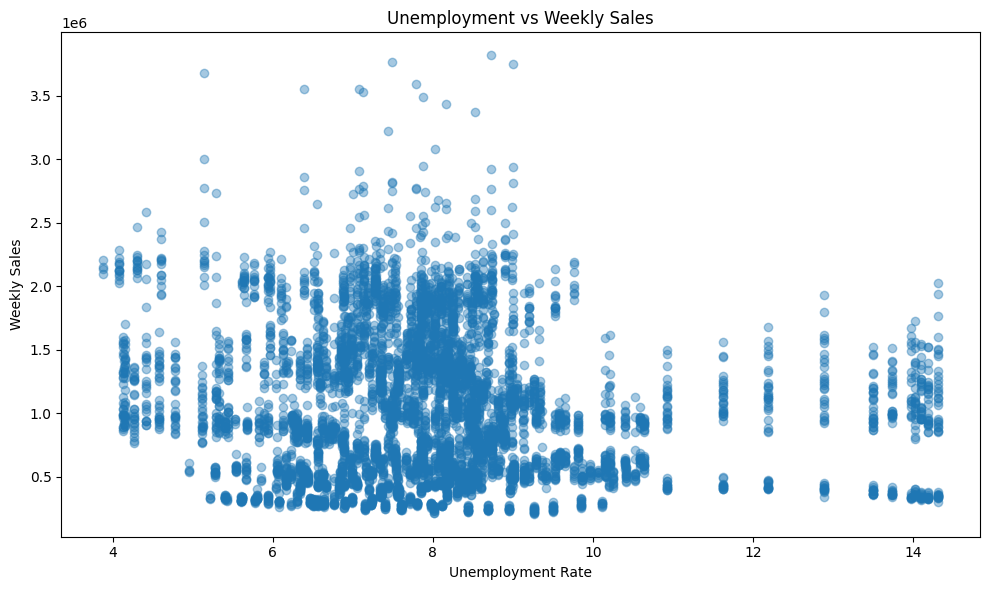

In [32]:
# Create scatter plot
plt.figure(figsize=(10, 6))

# Plot unemployment against weekly sales
plt.scatter(
    walmart_df['Unemployment'],
    walmart_df['Weekly_Sales'],
    alpha=0.4
)

# Add chart title
plt.title('Unemployment vs Weekly Sales')

# Label x-axis
plt.xlabel('Unemployment Rate')

# Label y-axis
plt.ylabel('Weekly Sales')

# Improve spacing
plt.tight_layout()

# Display chart
plt.show()

### Unemployment and Weekly Sales Findings

- The scatter plot shows substantial variation in weekly sales across similar unemployment rates.
- No strong linear relationship is visually apparent between unemployment and weekly sales.
- This supports the Pearson correlation of approximately **-0.106**, which indicates only a weak negative association.
- Higher unemployment observations generally contain fewer extremely high sales values, but the overall relationship remains weak.
- The wide variation in sales at similar unemployment levels suggests that other factors, such as store characteristics, holidays, and seasonality, are likely more important for explaining weekly sales differences.

# 21. Compare All External-Factor Correlations Visually

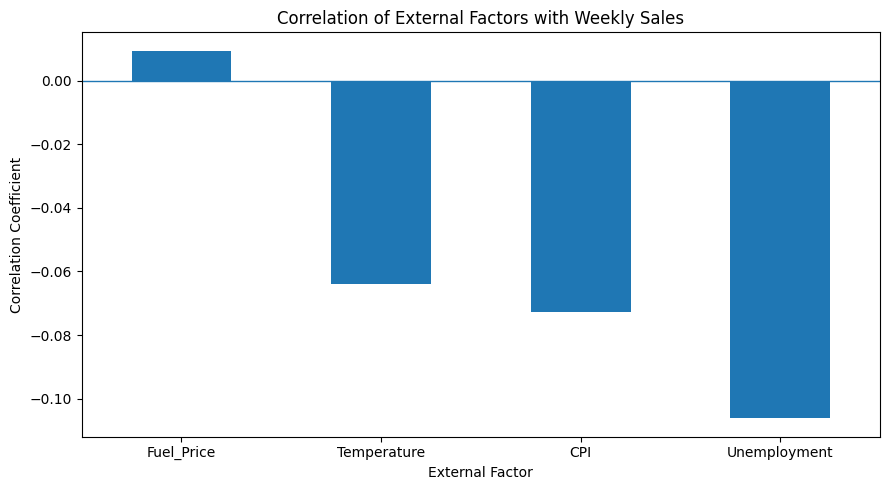

In [33]:
# Create correlations figure
plt.figure(figsize=(9,5))

# Plot correlation coefficients
sales_correlations.plot(kind='bar')

# Add chart title
plt.title('Correlation of External Factors with Weekly Sales')

# Label x-axis
plt.xlabel('External Factor')

# Label y-axis
plt.ylabel('Correlation Coefficient')

# Add zero reference line
plt.axhline(0, linewidth=1)

# Rotate factor labels
plt.xticks(rotation=0)

# Improve spacing
plt.tight_layout()

# Display chart
plt.show()


### External Factor Comparison Findings

- All four external factors showed correlations close to zero, indicating weak linear relationships with weekly sales.
- Fuel Price had almost no measurable linear association with weekly sales.
- Temperature and CPI showed small negative correlations.
- Unemployment had the strongest relationship among the external factors, but the correlation remained weak at approximately **-0.106**.
- Overall, the results suggest that these external factors individually explain relatively little of the variation in weekly sales.
- Store-level differences, seasonality, holidays, promotions, and other operational factors may be more important drivers of sales performance.

# 22. Consolidated Visualizations

## Top 10 Stores by Total Sales

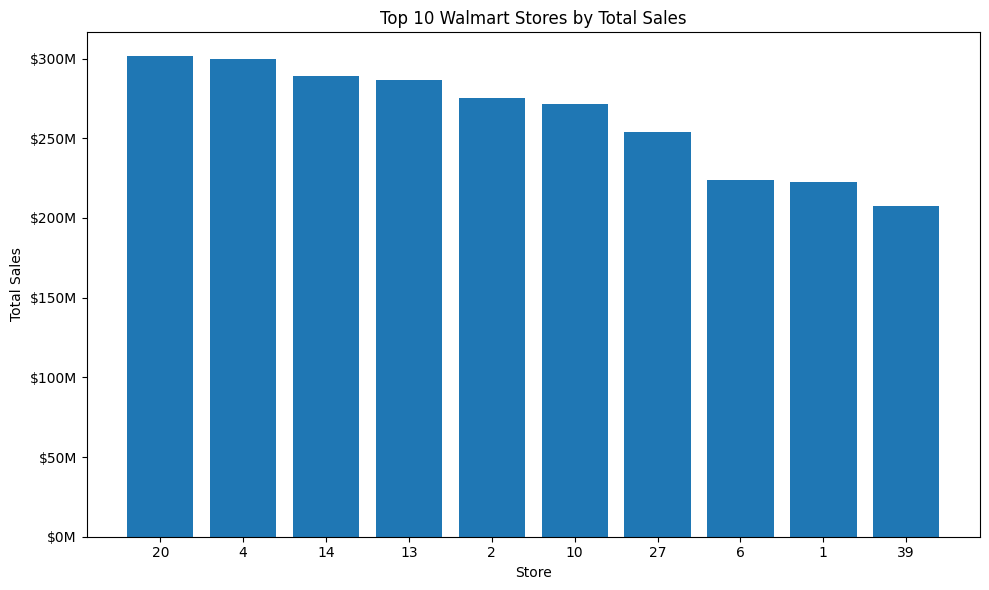

In [34]:
from matplotlib.pyplot import FuncFormatter

# Select top 10 stores
top_10_stores = store_sales.head(10)

# Create figure
plt.figure(figsize=(10,6))

# Plot total sales by store
plt.bar(
    top_10_stores['Store'].astype(str),
    top_10_stores['Total_Sales']
)

# Add chart title
plt.title('Top 10 Walmart Stores by Total Sales')

# Label x-axis
plt.xlabel('Store')

# Label y-axis
plt.ylabel('Total Sales')

# Format y-axis in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f'${value / 1_000_000:.0f}M'
    )
)

# Improve spacing
plt.tight_layout()

# Display chart
plt.show()

### Top 10 Store Sales Findings

- Store 20 generated the highest total sales at approximately **\$301.40 million**.
- Store 4 followed closely at approximately **\$299.54 million**.
- Stores 14 and 13 also exceeded **\$285 million** in total sales.
- The chart shows a clear decline in cumulative sales across the top-ranked stores, with Store 39 generating approximately **\$207.45 million**.

## Holiday vs Non-Holiday Sales

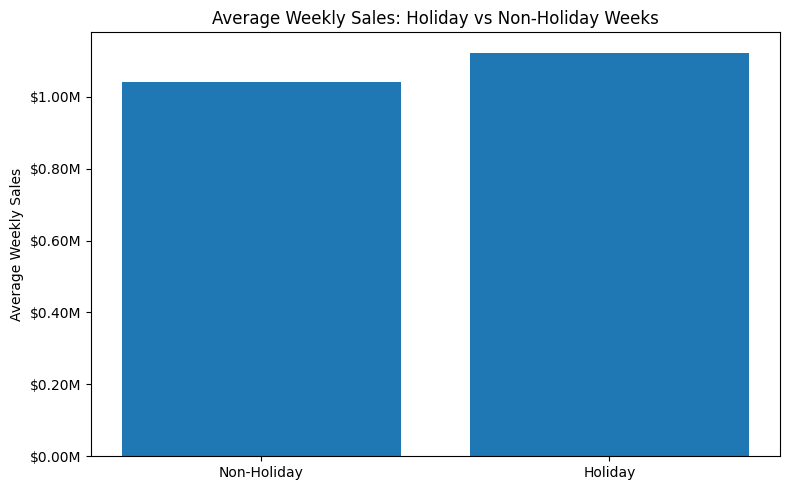

In [35]:
# Create figure
plt.figure(figsize=(8,5))

# Create holiday labels
holiday_labels = ['Non-Holiday','Holiday']

# Plot average weekly sales
plt.bar(
    holiday_labels,
    holiday_sales['Average_Weekly_Sales']
)

# Add chart title
plt.title('Average Weekly Sales: Holiday vs Non-Holiday Weeks')

# Label y-axis
plt.ylabel('Average Weekly Sales')

# Format y-axis in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f'${value / 1_000_000:.2f}M'
    )
)

# Improve Spacing
plt.tight_layout()

# Display chart
plt.show()

### Holiday vs Non-Holiday Sales Visualization

- Average weekly sales were approximately **\$1.12 million** during holiday weeks compared with approximately **\$1.04 million** during non-holiday weeks.
- Holiday weeks therefore generated about **7.8% higher average weekly sales**.
- The visual difference supports the earlier numerical comparison and suggests that holiday periods are associated with stronger sales performance.
- This relationship should be interpreted as an association rather than proof that holidays directly caused the increase in sales.

## Monthly Sales Trend

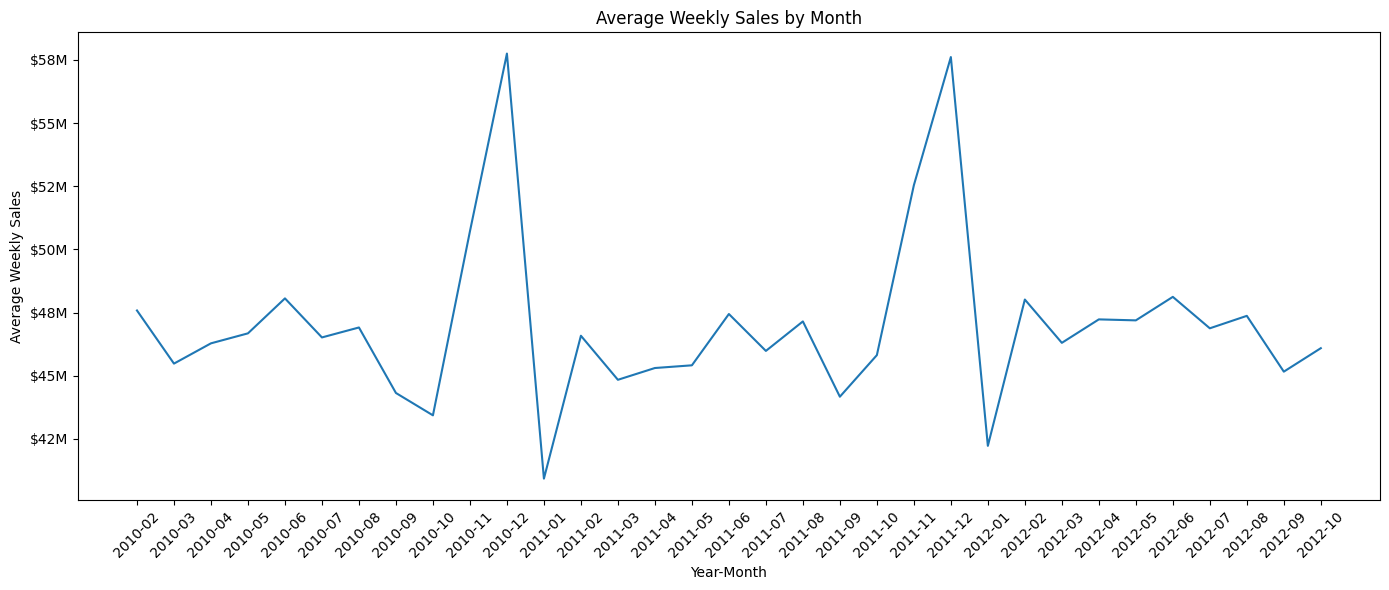

In [36]:
# Convert Year_Month to text
monthly_analysis['Year_Month_Label'] = (
    monthly_analysis['Year_Month']
    .astype(str)
)

# Create figure
plt.figure(figsize=(14,6))

# Plot average weekly sales by month
plt.plot(
    monthly_analysis['Year_Month_Label'],
    monthly_analysis['Average_Weekly_Sales']
)

# Add chart title
plt.title('Average Weekly Sales by Month')

# Label x-aixs
plt.xlabel('Year-Month')

# Label y-axis
plt.ylabel('Average Weekly Sales')

# Format y-axis in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f'${value / 1_000_000:.0f}M'
    )
)

# Rotate month labels
plt.xticks(rotation=45)

# Improve spacing
plt.tight_layout()

# Display chart
plt.show()

### Monthly Sales Trend Findings

- Average weekly sales show a recurring seasonal pattern across the observed period.
- December recorded the strongest average weekly sales in both 2010 and 2011, reaching approximately **\$58 million**.
- November also showed elevated sales in both years, particularly in 2011.
- Sales dropped sharply after the December peaks, with January showing substantially lower average weekly sales.
- The repeated November–December increase followed by a January decline provides strong evidence of year-end seasonality in Walmart sales.

## Store Sales Variability

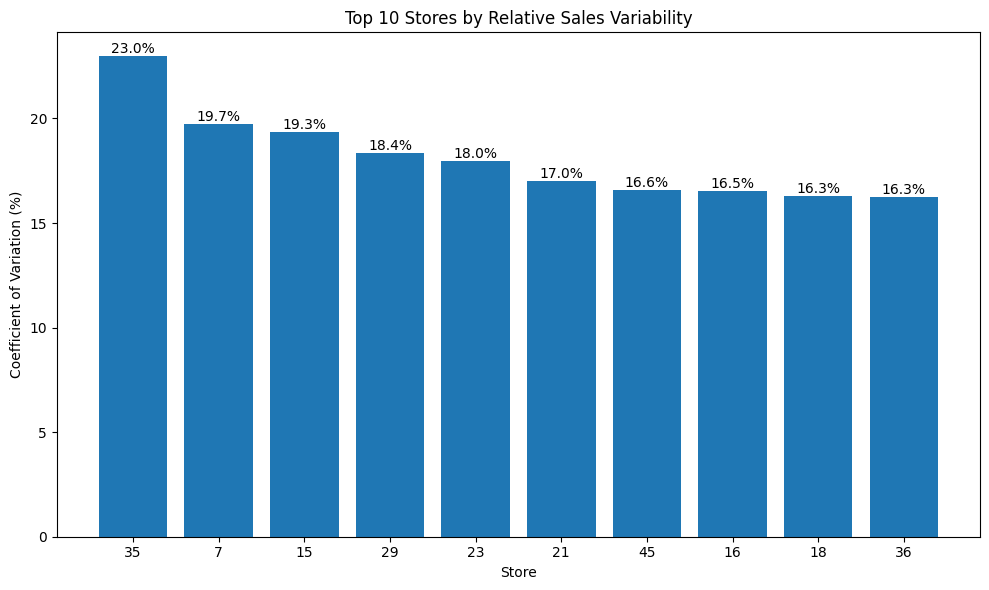

In [37]:
# Select top 10 variable stores
top_variable_stores = store_variability.head(10)

# Create figure
plt.figure(figsize=(10, 6))

# Plot coefficient of variation
bars = plt.bar(
    top_variable_stores['Store'].astype(str),
    top_variable_stores['CV_Percent']
)

# Add chart title
plt.title('Top 10 Stores by Relative Sales Variability')

# Label x-axis
plt.xlabel('Store')

# Label y-axis
plt.ylabel('Coefficient of Variation (%)')

# Add percentage labels
plt.bar_label(
    bars,
    fmt='%.1f%%'
)

# Improve spacing
plt.tight_layout()

# Display chart
plt.show()

### Store Sales Variability Findings

- Store 35 had the highest coefficient of variation at approximately **23.0%**, indicating the greatest relative variability in weekly sales.
- Stores 7 and 15 followed with coefficients of variation of approximately **19.7%** and **19.3%**.
- The coefficient of variation adjusts sales volatility for each store's average sales level, making it more useful than standard deviation alone for comparing stores of different sizes.
- Higher variability does not necessarily indicate poor performance; it may reflect stronger seasonality, promotional activity, or unusually large sales spikes.

## Yearly Average Weekly Sales

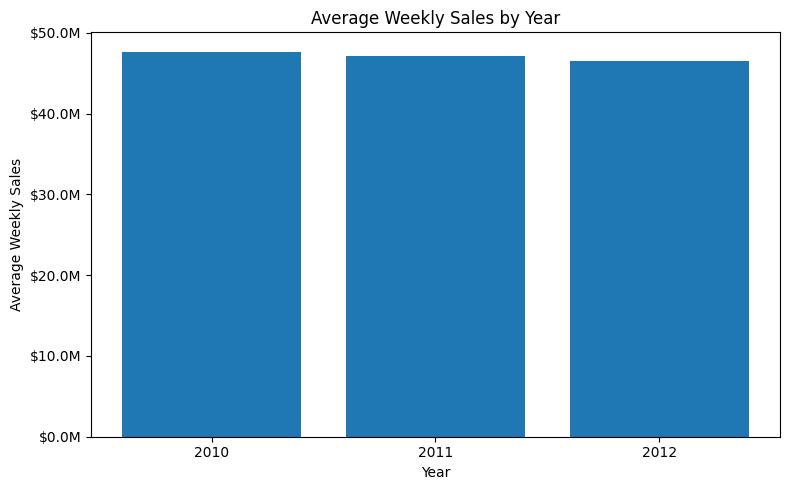

In [38]:
# Create figure
plt.figure(figsize=(8, 5))

# Plot yearly average weekly sales
plt.bar(
    yearly_analysis['Year'].astype(str),
    yearly_analysis['Average_Weekly_Sales']
)

# Add chart title
plt.title('Average Weekly Sales by Year')

# Label x-axis
plt.xlabel('Year')

# Label y-axis
plt.ylabel('Average Weekly Sales')

# Format y-axis in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f'${value / 1_000_000:.1f}M'
    )
)

# Improve spacing
plt.tight_layout()

# Display chart
plt.show()

### Yearly Average Weekly Sales Findings

- Average weekly sales were highest in 2010 at approximately **\$47.69 million**.
- Average weekly sales declined slightly to approximately **\$47.08 million** in 2011.
- In 2012, average weekly sales decreased further to approximately **\$46.51 million**.
- The differences between years are relatively small, indicating a gradual rather than substantial decline in average weekly sales.
- Because 2010 and 2012 contain fewer observed weeks than 2011, these results should not be interpreted as a complete calendar-year growth comparison.

# 23. Key Findings



1. **Store 20 was the strongest-performing store by total sales**, generating approximately **\$301.40 million** across the observed period. Store 4 followed closely at approximately **\$299.54 million**.

2. **Holiday weeks outperformed non-holiday weeks**, with average weekly sales of approximately **\$1.12 million** compared with **\$1.04 million**, representing an increase of about **7.8%**.

3. **Sales showed clear year-end seasonality.** December 2010 and December 2011 had the highest average weekly sales, both reaching approximately **\$58 million** across all stores.

4. **November was also a consistently strong month**, reinforcing the pattern of elevated sales during the late-year period.

5. **Store 35 had the highest relative sales variability**, with a coefficient of variation of approximately **23.0%**, indicating greater week-to-week fluctuation relative to its average sales level.

6. **Average weekly sales declined slightly across the observed years**, from approximately **\$47.69 million in 2010** to **\$46.51 million in 2012**. However, 2010 and 2012 represent partial-year periods, so this should not be treated as a complete year-over-year comparison.

7. **External economic factors showed weak linear relationships with weekly sales.** Unemployment had the strongest correlation at approximately **-0.106**, while Fuel Price was nearly uncorrelated with sales.

8. Overall, the analysis suggests that **store-level differences and seasonal patterns are more strongly reflected in sales performance than the external economic variables examined individually**.

# 24. Business Recommendations



 **Prepare additional inventory and staffing for November and December**, when weekly sales historically reach their highest levels.
- **Use top-performing stores such as Stores 20 and 4 as internal benchmarks** to investigate operational practices that may contribute to strong sales performance.
- **Review highly variable stores such as Store 35 more closely** to determine whether volatility is associated with seasonality, promotions, local demand, or operational factors.
- **Incorporate holiday indicators into sales forecasting models**, since holiday weeks were associated with approximately 7.8% higher average weekly sales.
- **Avoid relying on individual external economic variables alone for sales forecasting**, because Temperature, Fuel Price, CPI, and Unemployment showed weak linear correlations with weekly sales.
- **Combine store-level, seasonal, holiday, and economic variables in future predictive analysis** to evaluate whether they provide stronger explanatory or forecasting power when considered together.